# Compressor de imagens ICV2

## DCT + quantização + RLE + Huffman adaptativo

Este notebook implementa, sem funções prontas de compressão, um codec **com perdas** para imagens em tons de cinza. O fluxo completo é:

1. leitura da imagem (única função pronta de E/S de imagem);
2. preenchimento das bordas e divisão em blocos 8×8;
3. deslocamento de nível e DCT bidimensional;
4. quantização controlada pelo parâmetro `QUALIDADE`;
5. varredura zig-zag, diferença entre coeficientes DC e RLE dos coeficientes AC;
6. Huffman adaptativo e escrita bit a bit em um arquivo `.icv`;
7. leitura desse arquivo, decodificação própria, IDCT e recorte;
8. cálculo de PSNR e taxa de compressão.

A DCT é a única transformação pronta empregada, conforme permitido pelo enunciado. Não são usados JPEG, PNG, ZIP, `pickle` ou funções prontas de codificação/decodificação. O formato ICV2 armazena dimensões, qualidade, frequências de Huffman, quantidade válida de bits e o fluxo comprimido.

As métricas adotadas são:

$$\mathrm{PSNR}=10\log_{10}\left(\frac{255^2}{\mathrm{MSE}}\right),\qquad
\mathrm{TC}=\frac{H\times W}{\text{bytes do arquivo ICV2}}.$$

Assim, `TC = 3` significa que o arquivo codificado ocupa aproximadamente um terço da representação crua de 8 bits por pixel.

## 1. Inicialização e parâmetros

Altere somente `NOME_IMAGEM` e `QUALIDADE` para testar outra imagem. O valor 90 foi escolhido para manter boa qualidade visual e superar simultaneamente 33 dB e taxa 2 nas quatro imagens fornecidas.

In [1]:
%matplotlib inline
import csv
import heapq
import math
import os
import struct
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dct, idct

NOME_IMAGEM = 'lena.pgm'
QUALIDADE = 90                 # intervalo válido: 1 a 100
DIRETORIO_SAIDA = Path('saida')
DIRETORIO_SAIDA.mkdir(exist_ok=True)

print('Python:', __import__('sys').version.split()[0])
print('Imagem selecionada:', NOME_IMAGEM)
print('Qualidade:', QUALIDADE)

Python: 3.12.14
Imagem selecionada: lena.pgm
Qualidade: 90


## 2. Leitura da imagem

A função procura primeiro no diretório do notebook e depois em `upload/`. Isso facilita a correção: basta colocar uma nova imagem PGM ao lado do notebook e alterar `NOME_IMAGEM`. Imagens coloridas são convertidas para luminância apenas na etapa de leitura; o codec recebe sempre uma matriz 2-D de 8 bits.

Caminho: upload/lena.pgm
Dimensões: 512 x 512
Faixa de níveis: 25 a 245


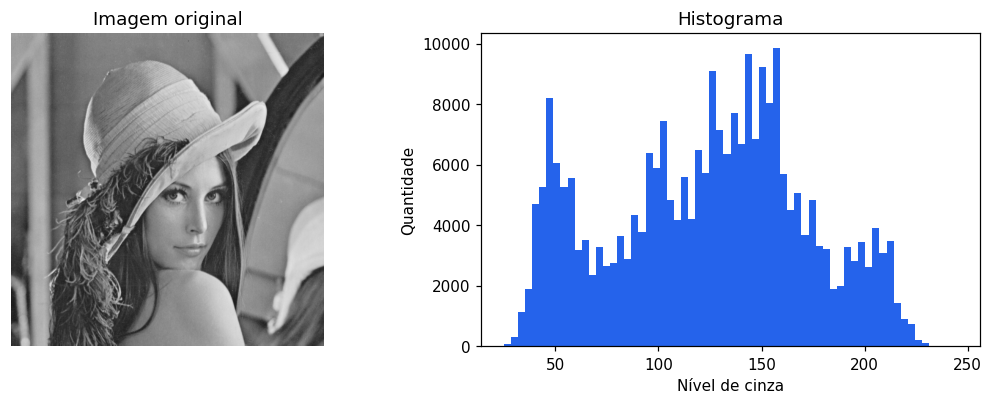

In [2]:
def localizar_imagem(nome):
    candidatos = [Path(nome), Path('upload') / nome, Path('imagens') / nome]
    for candidato in candidatos:
        if candidato.exists():
            return candidato
    raise IOError('Imagem não encontrada. Caminhos testados: ' +
                  ', '.join(str(p) for p in candidatos))


def ler_imagem_cinza(caminho):
    return np.array(Image.open(str(caminho)).convert('L'), dtype=np.uint8)


caminho_imagem = localizar_imagem(NOME_IMAGEM)
imagem = ler_imagem_cinza(caminho_imagem)

print('Caminho:', caminho_imagem)
print('Dimensões: {} x {}'.format(imagem.shape[1], imagem.shape[0]))
print('Faixa de níveis: {} a {}'.format(int(imagem.min()), int(imagem.max())))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].imshow(imagem, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagem original')
axes[0].axis('off')
axes[1].hist(imagem.ravel(), bins=64, color='#2563eb')
axes[1].set_title('Histograma')
axes[1].set_xlabel('Nível de cinza')
axes[1].set_ylabel('Quantidade')
plt.tight_layout()
plt.show()

## 3. Transformada, quantização e zig-zag

Cada bloco tem 128 subtraído de seus pixels e passa por uma DCT ortonormal 2-D. A energia tende a se concentrar no canto superior esquerdo. A tabela de luminância é escalada pelo parâmetro de qualidade: valores altos usam passos menores, preservam mais coeficientes e produzem arquivos maiores. O zig-zag coloca primeiro as baixas frequências e cria longas caudas de zeros, apropriadas ao RLE.

In [3]:
Q_BASE = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float64)


def zigzag_indices(n=8):
    indices = []
    for total in range(2 * n - 1):
        diagonal = []
        r0 = max(0, total - n + 1)
        r1 = min(n - 1, total)
        for r in range(r0, r1 + 1):
            diagonal.append((r, total - r))
        if total % 2 == 0:
            diagonal.reverse()
        indices.extend(diagonal)
    return indices


ZZ = zigzag_indices(8)


def qtable(quality):
    quality = int(np.clip(quality, 1, 100))
    scale = 5000.0 / quality if quality < 50 else 200.0 - 2.0 * quality
    return np.clip(np.floor((Q_BASE * scale + 50.0) / 100.0), 1, 255)


def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')


def idct2(coeff):
    return idct(idct(coeff.T, norm='ortho').T, norm='ortho')

Tabela de quantização (qualidade=90):
[[ 3  2  2  3  5  8 10 12]
 [ 2  2  3  4  5 12 12 11]
 [ 3  3  3  5  8 11 14 11]
 [ 3  3  4  6 10 17 16 12]
 [ 4  4  7 11 14 22 21 15]
 [ 5  7 11 13 16 21 23 18]
 [10 13 16 17 21 24 24 20]
 [14 18 19 20 22 20 21 20]]

Coeficientes quantizados do primeiro bloco:
[[86  2  2  0  0  0  0  0]
 [ 4  0  0 -1  0  0  0  0]
 [-2  0 -1  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]]

Primeiros 20 valores em zig-zag:
[86, 2, 4, -2, 0, 2, 0, 0, 0, 1, 0, 0, -1, -1, 0, 0, 0, 0, 0, 0]


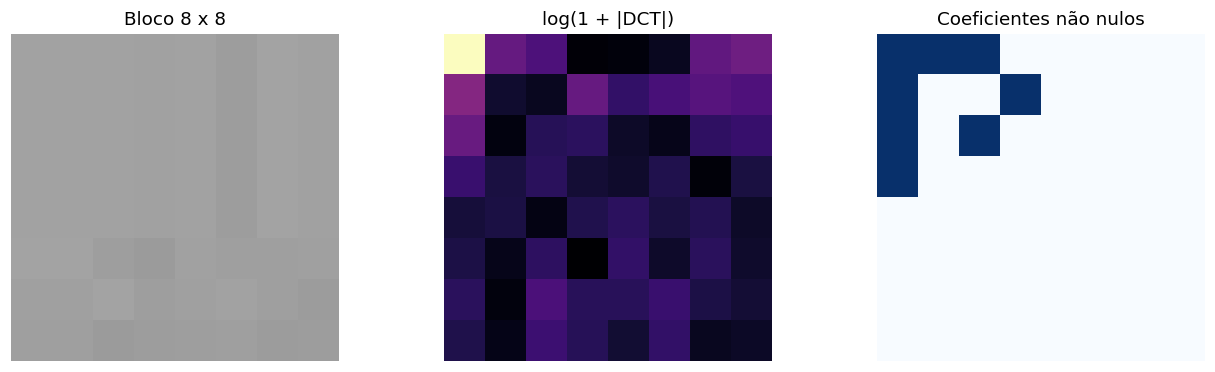

In [4]:
# Exemplo intermediário com o primeiro bloco 8 x 8.
bloco = pad_exemplo = np.pad(imagem, ((0, (-imagem.shape[0]) % 8),
                                      (0, (-imagem.shape[1]) % 8)), mode='edge')[:8, :8]
coeficientes = dct2(bloco.astype(np.float64) - 128.0)
tabela_q = qtable(QUALIDADE)
quantizado = np.rint(coeficientes / tabela_q).astype(np.int32)
sequencia_zigzag = [int(quantizado[r, c]) for r, c in ZZ]

print('Tabela de quantização (qualidade={}):\n{}'.format(QUALIDADE, tabela_q.astype(int)))
print('\nCoeficientes quantizados do primeiro bloco:\n{}'.format(quantizado))
print('\nPrimeiros 20 valores em zig-zag:\n{}'.format(sequencia_zigzag[:20]))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(bloco, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Bloco 8 x 8')
axes[1].imshow(np.log1p(np.abs(coeficientes)), cmap='magma')
axes[1].set_title('log(1 + |DCT|)')
axes[2].imshow(quantizado != 0, cmap='Blues')
axes[2].set_title('Coeficientes não nulos')
for eixo in axes:
    eixo.axis('off')
plt.tight_layout()
plt.show()

## 4. Entrada e saída de bits

As classes abaixo acumulam e recuperam bits individualmente. Elas são usadas tanto pelos códigos de Huffman quanto pelos bits de amplitude. Os métodos Exp-Golomb permanecem implementados como uma alternativa didática, embora o fluxo final use Huffman adaptativo por produzir arquivos menores.

In [5]:
class BitWriter(object):
    def __init__(self):
        self.data = bytearray()
        self.current = 0
        self.used = 0
        self.bit_count = 0

    def write_bit(self, bit):
        self.current = (self.current << 1) | (1 if bit else 0)
        self.used += 1
        self.bit_count += 1
        if self.used == 8:
            self.data.append(self.current)
            self.current = 0
            self.used = 0

    def write_bits(self, value, count):
        for shift in range(count - 1, -1, -1):
            self.write_bit((value >> shift) & 1)

    def write_ue(self, value):
        code_num = int(value) + 1
        zeros = code_num.bit_length() - 1
        for _ in range(zeros):
            self.write_bit(0)
        self.write_bits(code_num, zeros + 1)

    def write_se(self, value):
        value = int(value)
        mapped = 2 * value - 1 if value > 0 else -2 * value
        self.write_ue(mapped)

    def finish(self):
        if self.used:
            self.data.append(self.current << (8 - self.used))
            self.current = 0
            self.used = 0
        return bytes(self.data), self.bit_count


class BitReader(object):
    def __init__(self, data, bit_count):
        self.data = data
        self.bit_count = int(bit_count)
        self.position = 0

    def read_bit(self):
        if self.position >= self.bit_count:
            raise ValueError('Fim inesperado do fluxo de bits')
        byte = self.data[self.position // 8]
        bit = (byte >> (7 - self.position % 8)) & 1
        self.position += 1
        return bit

    def read_bits(self, count):
        value = 0
        for _ in range(count):
            value = (value << 1) | self.read_bit()
        return value

    def read_ue(self):
        zeros = 0
        while self.read_bit() == 0:
            zeros += 1
            if zeros > 31:
                raise ValueError('Código Exp-Golomb inválido')
        suffix = self.read_bits(zeros) if zeros else 0
        return (1 << zeros) + suffix - 1

    def read_se(self):
        mapped = self.read_ue()
        return (mapped + 1) // 2 if mapped % 2 else -(mapped // 2)

## 5. Huffman adaptativo e representação dos coeficientes

Para DC, codifica-se a categoria do valor diferencial. Para AC, cada símbolo reúne a sequência de zeros (`run`) e a quantidade de bits da amplitude. `EOB` encerra antecipadamente uma cauda de zeros e `ZRL` representa dezesseis zeros. As frequências observadas são guardadas no cabeçalho; por isso, o decodificador reconstrói exatamente as mesmas árvores sem qualquer biblioteca de compressão.

In [6]:
def magnitude_category(value):
    return abs(int(value)).bit_length()


def amplitude_bits(value, category):
    value = int(value)
    return value if value >= 0 else ((1 << category) - 1 + value)


def amplitude_value(bits, category):
    if category == 0:
        return 0
    threshold = 1 << (category - 1)
    return bits if bits >= threshold else bits - (1 << category) + 1


def build_huffman_codes(frequencies):
    """Constrói códigos de Huffman determinísticos a partir das frequências."""
    heap = []
    order = 0
    for symbol, frequency in enumerate(frequencies):
        if frequency:
            heapq.heappush(heap, (int(frequency), order, symbol))
            order += 1
    if not heap:
        raise ValueError('Tabela de frequências vazia')
    if len(heap) == 1:
        only_symbol = heap[0][2]
        return {only_symbol: (0, 1)}
    while len(heap) > 1:
        f1, _, left = heapq.heappop(heap)
        f2, _, right = heapq.heappop(heap)
        heapq.heappush(heap, (f1 + f2, order, (left, right)))
        order += 1
    root = heap[0][2]
    codes = {}

    def visit(node, code, length):
        if isinstance(node, int):
            codes[node] = (code, length)
        else:
            visit(node[0], code << 1, length + 1)
            visit(node[1], (code << 1) | 1, length + 1)
    visit(root, 0, 0)
    return codes


def invert_huffman_codes(codes):
    return {(length, code): symbol for symbol, (code, length) in codes.items()}


def write_huffman(writer, codes, symbol):
    code, length = codes[int(symbol)]
    writer.write_bits(code, length)


def read_huffman(reader, decoder):
    code = 0
    for length in range(1, 33):
        code = (code << 1) | reader.read_bit()
        key = (length, code)
        if key in decoder:
            return decoder[key]
    raise ValueError('Código de Huffman inválido')

## 6. Codificador e decodificador ICV2

O codificador faz duas passagens: primeiro quantiza os blocos e conta símbolos; depois cria as árvores e escreve os códigos. O decodificador lê exclusivamente o arquivo salvo, refaz as árvores, recupera os blocos e aplica a IDCT. O preenchimento por repetição de borda permite dimensões que não sejam múltiplas de oito.

In [7]:
def pad_image(image):
    h, w = image.shape
    hp = int(math.ceil(h / 8.0) * 8)
    wp = int(math.ceil(w / 8.0) * 8)
    return np.pad(image, ((0, hp - h), (0, wp - w)), mode='edge')


def encode_array(image, quality):
    image = np.asarray(image, dtype=np.uint8)
    if image.ndim != 2:
        raise ValueError('Esta versão aceita imagens em tons de cinza (matriz 2-D).')
    padded = pad_image(image)
    h, w = image.shape
    qt = qtable(quality)
    blocks = []
    dc_frequency = [0] * 16
    ac_frequency = [0] * 256
    previous_dc = 0
    nonzero = 0
    total = 0
    for y in range(0, padded.shape[0], 8):
        for x in range(0, padded.shape[1], 8):
            block = padded[y:y + 8, x:x + 8].astype(np.float64) - 128.0
            quantized = np.rint(dct2(block) / qt).astype(np.int32)
            sequence = [int(quantized[r, c]) for r, c in ZZ]
            dc_difference = sequence[0] - previous_dc
            previous_dc = sequence[0]
            dc_category = magnitude_category(dc_difference)
            if dc_category > 15:
                raise ValueError('Categoria DC fora do formato')
            dc_frequency[dc_category] += 1
            ac_tokens = []
            pos = 1
            while pos < 64:
                next_pos = pos
                while next_pos < 64 and sequence[next_pos] == 0:
                    next_pos += 1
                if next_pos == 64:
                    ac_tokens.append((0, 0, 0))  # EOB
                    ac_frequency[0] += 1
                    break
                run = next_pos - pos
                while run >= 16:
                    ac_tokens.append((0xF0, 0, 0))  # ZRL
                    ac_frequency[0xF0] += 1
                    run -= 16
                value = sequence[next_pos]
                category = magnitude_category(value)
                if category > 15:
                    raise ValueError('Categoria AC fora do formato')
                symbol = (run << 4) | category
                ac_tokens.append((symbol, value, category))
                ac_frequency[symbol] += 1
                pos = next_pos + 1
            blocks.append((dc_difference, dc_category, ac_tokens))
            nonzero += int(np.count_nonzero(quantized))
            total += 64

    dc_codes = build_huffman_codes(dc_frequency)
    ac_codes = build_huffman_codes(ac_frequency)
    writer = BitWriter()
    for dc_difference, dc_category, ac_tokens in blocks:
        write_huffman(writer, dc_codes, dc_category)
        if dc_category:
            writer.write_bits(amplitude_bits(dc_difference, dc_category), dc_category)
        for symbol, value, category in ac_tokens:
            write_huffman(writer, ac_codes, symbol)
            if category:
                writer.write_bits(amplitude_bits(value, category), category)
    payload, bit_count = writer.finish()
    fixed_header = struct.pack('<4sIIBBI', b'ICV2', h, w, int(quality), 8, bit_count)
    frequency_header = struct.pack('<16I', *dc_frequency) + struct.pack('<256I', *ac_frequency)
    header = fixed_header + frequency_header
    stats = {'nonzero': nonzero, 'total_coefficients': total,
             'payload_bits': bit_count, 'header_bytes': len(header)}
    return header + payload, stats


def decode_bytes(coded):
    fixed_size = struct.calcsize('<4sIIBBI')
    frequency_size = struct.calcsize('<16I') + struct.calcsize('<256I')
    header_size = fixed_size + frequency_size
    if len(coded) < header_size:
        raise ValueError('Arquivo truncado')
    magic, h, w, quality, block_size, bit_count = struct.unpack(
        '<4sIIBBI', coded[:fixed_size])
    if magic != b'ICV2' or block_size != 8:
        raise ValueError('Formato ICV inválido ou não suportado')
    offset = fixed_size
    dc_frequency = struct.unpack('<16I', coded[offset:offset + struct.calcsize('<16I')])
    offset += struct.calcsize('<16I')
    ac_frequency = struct.unpack('<256I', coded[offset:offset + struct.calcsize('<256I')])
    dc_decoder = invert_huffman_codes(build_huffman_codes(dc_frequency))
    ac_decoder = invert_huffman_codes(build_huffman_codes(ac_frequency))
    payload = coded[header_size:]
    if len(payload) * 8 < bit_count:
        raise ValueError('Fluxo de bits truncado')
    reader = BitReader(payload, bit_count)
    hp = int(math.ceil(h / 8.0) * 8)
    wp = int(math.ceil(w / 8.0) * 8)
    reconstructed = np.zeros((hp, wp), dtype=np.float64)
    qt = qtable(quality)
    previous_dc = 0
    for y in range(0, hp, 8):
        for x in range(0, wp, 8):
            sequence = [0] * 64
            dc_category = read_huffman(reader, dc_decoder)
            dc_bits = reader.read_bits(dc_category) if dc_category else 0
            previous_dc += amplitude_value(dc_bits, dc_category)
            sequence[0] = previous_dc
            pos = 1
            while pos < 64:
                symbol = read_huffman(reader, ac_decoder)
                if symbol == 0:
                    break
                if symbol == 0xF0:
                    pos += 16
                    if pos > 64:
                        raise ValueError('ZRL inválido no fluxo codificado')
                    continue
                run = symbol >> 4
                category = symbol & 0x0F
                pos += int(run)
                if pos >= 64:
                    raise ValueError('RLE inválido no fluxo codificado')
                bits = reader.read_bits(category)
                sequence[pos] = amplitude_value(bits, category)
                pos += 1
            quantized = np.zeros((8, 8), dtype=np.float64)
            for value, (r, c) in zip(sequence, ZZ):
                quantized[r, c] = value
            reconstructed[y:y + 8, x:x + 8] = idct2(quantized * qt) + 128.0
    return np.clip(np.rint(reconstructed[:h, :w]), 0, 255).astype(np.uint8)


def save_encoded(path, image, quality):
    coded, stats = encode_array(image, quality)
    with open(str(path), 'wb') as stream:
        stream.write(coded)
    return stats


def load_encoded(path):
    with open(str(path), 'rb') as stream:
        return decode_bytes(stream.read())


def psnr(original, reconstructed):
    error = np.mean((original.astype(np.float64) - reconstructed.astype(np.float64)) ** 2)
    return float('inf') if error == 0 else 10.0 * math.log10((255.0 ** 2) / error)

## 7. Codificação no disco e decodificação do arquivo salvo

Esta é a execução completa exigida pelo enunciado. A reconstrução abaixo não usa variáveis internas do codificador: ela é produzida pela leitura do `.icv` gravado em disco.

In [8]:
arquivo_codificado = DIRETORIO_SAIDA / (Path(NOME_IMAGEM).stem + '_q' +
                                                 str(QUALIDADE) + '.icv')
estatisticas = save_encoded(arquivo_codificado, imagem, QUALIDADE)
reconstruida = load_encoded(arquivo_codificado)

assert reconstruida.shape == imagem.shape
print('Arquivo salvo em:', arquivo_codificado)
print('Bytes codificados:', arquivo_codificado.stat().st_size)
print('Bits úteis no payload:', estatisticas['payload_bits'])
print('Coeficientes não nulos: {:.2f}%'.format(
    100.0 * estatisticas['nonzero'] / estatisticas['total_coefficients']))

Arquivo salvo em: saida/lena_q90.icv
Bytes codificados: 58647
Bits úteis no payload: 460327
Coeficientes não nulos: 29.65%


## 8. Reconstrução, erro e métricas

O mapa de erro absoluto evidencia onde a quantização retirou informação. Para tornar a comparação honesta, a taxa usa a representação crua de 8 bits por pixel no numerador e inclui todo o cabeçalho no tamanho comprimido.

PSNR: 40.786 dB
Taxa de compressão: 4.470:1
Erro absoluto médio: 1.760
Erro absoluto máximo: 22


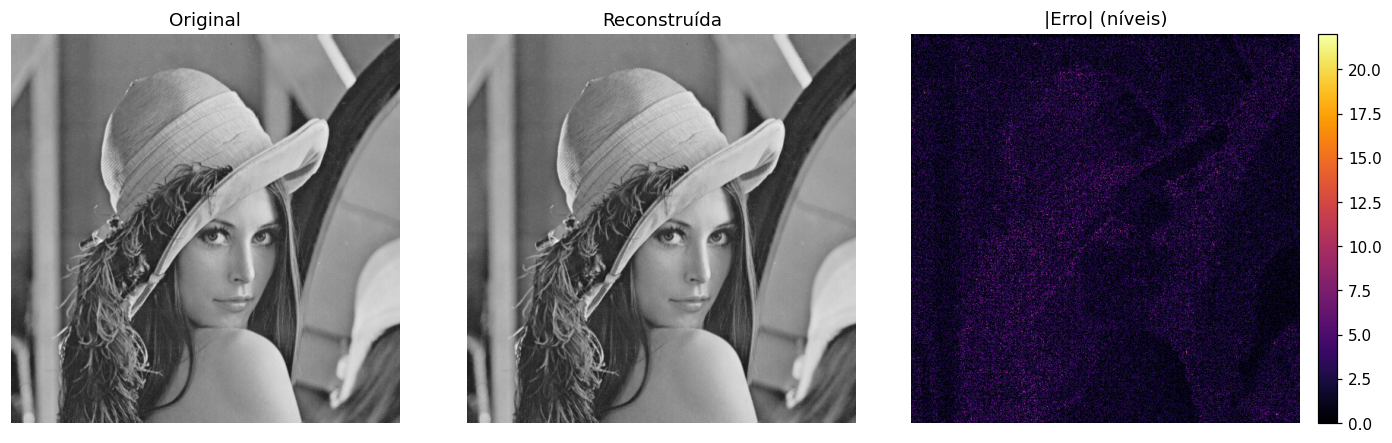

In [9]:
valor_psnr = psnr(imagem, reconstruida)
bytes_crus = int(imagem.size)
bytes_codificados = int(arquivo_codificado.stat().st_size)
taxa_compressao = bytes_crus / float(bytes_codificados)
erro_absoluto = np.abs(imagem.astype(np.int16) - reconstruida.astype(np.int16))

print('PSNR: {:.3f} dB'.format(valor_psnr))
print('Taxa de compressão: {:.3f}:1'.format(taxa_compressao))
print('Erro absoluto médio: {:.3f}'.format(float(erro_absoluto.mean())))
print('Erro absoluto máximo:', int(erro_absoluto.max()))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(imagem, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[1].imshow(reconstruida, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Reconstruída')
mapa = axes[2].imshow(erro_absoluto, cmap='inferno', vmin=0)
axes[2].set_title('|Erro| (níveis)')
for eixo in axes:
    eixo.axis('off')
fig.colorbar(mapa, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 9. Experimento padronizado nas quatro imagens

Todas as imagens usam exatamente `QUALIDADE = 90`. Além de tornar a comparação reproduzível, isso evita escolher parâmetros diferentes depois de observar cada resultado. Os arquivos `.icv` são efetivamente gravados e relidos antes do cálculo do PSNR.

Imagem            Bytes crus   Bytes ICV       Taxa    PSNR (dB)
----------------------------------------------------------------
baboon.pgm            240000      109133     2.199:1       36.577
cameraman.pgm          65536       20539     3.191:1       39.093
lena.pgm              262144       58647     4.470:1       40.786
unequal.pgm           160000       16981     9.422:1       47.572


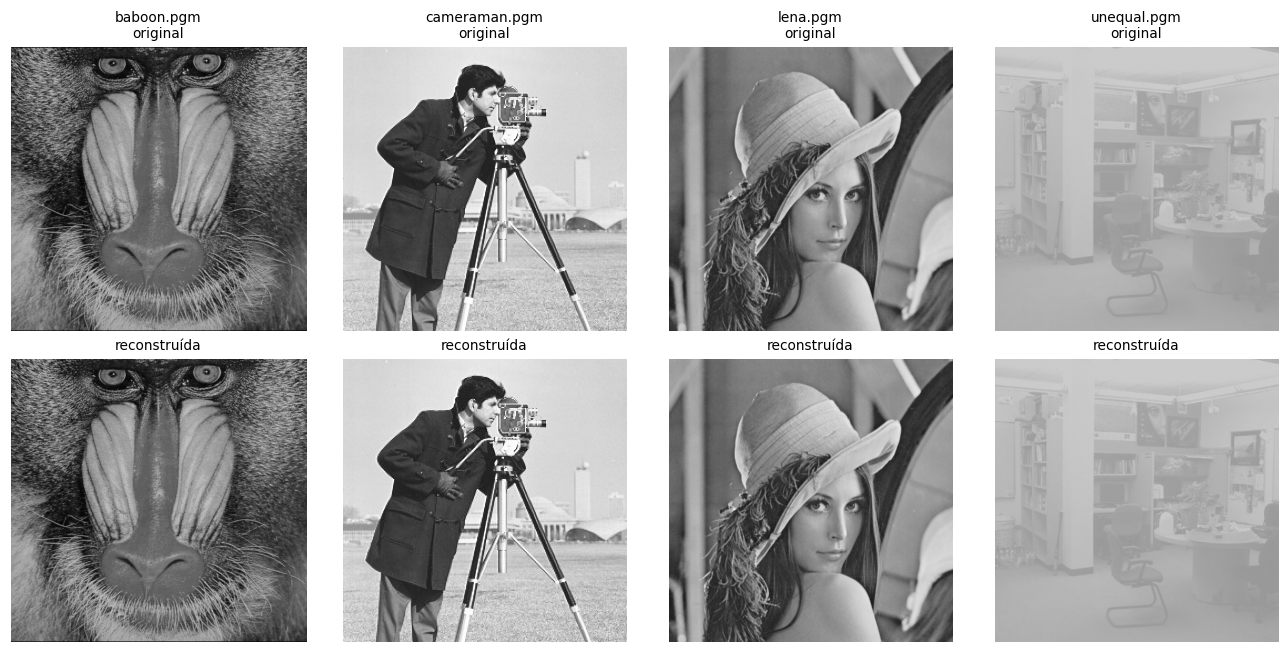

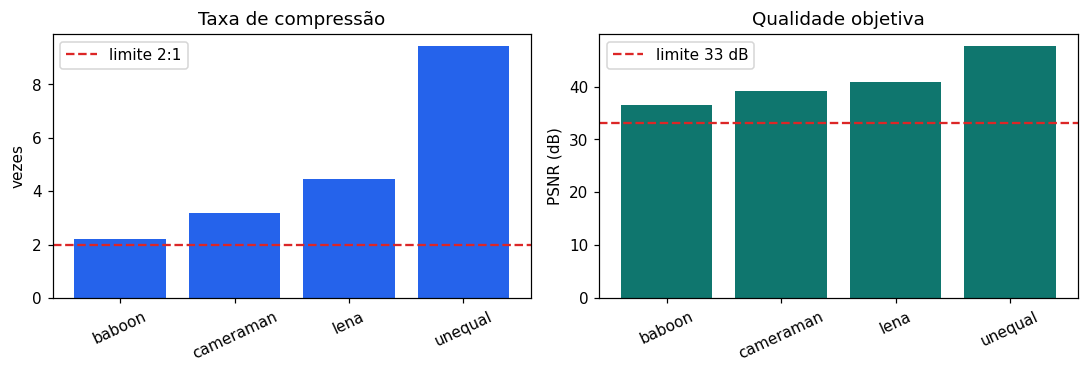

In [10]:
nomes_teste = ['baboon.pgm', 'cameraman.pgm', 'lena.pgm', 'unequal.pgm']
resultados = []
pares = []

for nome in nomes_teste:
    caminho = localizar_imagem(nome)
    original = ler_imagem_cinza(caminho)
    destino = DIRETORIO_SAIDA / (Path(nome).stem + '_q90.icv')
    stats = save_encoded(destino, original, 90)
    recuperada = load_encoded(destino)
    resultado = {
        'imagem': nome,
        'largura': int(original.shape[1]),
        'altura': int(original.shape[0]),
        'bytes_crus': int(original.size),
        'bytes_icv': int(destino.stat().st_size),
        'taxa': original.size / float(destino.stat().st_size),
        'psnr': psnr(original, recuperada),
        'nao_nulos_pct': 100.0 * stats['nonzero'] / stats['total_coefficients']
    }
    resultados.append(resultado)
    pares.append((original, recuperada))

cabecalho = '{:<16} {:>11} {:>11} {:>10} {:>12}'.format(
    'Imagem', 'Bytes crus', 'Bytes ICV', 'Taxa', 'PSNR (dB)')
print(cabecalho)
print('-' * len(cabecalho))
for r in resultados:
    print('{:<16} {:>11d} {:>11d} {:>9.3f}:1 {:>12.3f}'.format(
        r['imagem'], r['bytes_crus'], r['bytes_icv'], r['taxa'], r['psnr']))

# Salva uma cópia textual dos resultados para facilitar a reprodução do relatório.
with open(str(DIRETORIO_SAIDA / 'resultados.csv'), 'w', newline='') as arquivo_csv:
    escritor = csv.writer(arquivo_csv)
    escritor.writerow(['imagem', 'largura', 'altura', 'bytes_crus', 'bytes_icv',
                        'taxa_compressao', 'psnr_db', 'coeficientes_nao_nulos_pct'])
    for r in resultados:
        escritor.writerow([r['imagem'], r['largura'], r['altura'], r['bytes_crus'],
                            r['bytes_icv'], '{:.6f}'.format(r['taxa']),
                            '{:.6f}'.format(r['psnr']),
                            '{:.6f}'.format(r['nao_nulos_pct'])])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for coluna, (nome, par) in enumerate(zip(nomes_teste, pares)):
    axes[0, coluna].imshow(par[0], cmap='gray', vmin=0, vmax=255)
    axes[0, coluna].set_title(nome + '\noriginal', fontsize=9)
    axes[1, coluna].imshow(par[1], cmap='gray', vmin=0, vmax=255)
    axes[1, coluna].set_title('reconstruída', fontsize=9)
    axes[0, coluna].axis('off')
    axes[1, coluna].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
rotulos = [r['imagem'].replace('.pgm', '') for r in resultados]
axes[0].bar(rotulos, [r['taxa'] for r in resultados], color='#2563eb')
axes[0].axhline(2.0, color='#dc2626', linestyle='--', label='limite 2:1')
axes[0].set_title('Taxa de compressão')
axes[0].set_ylabel('vezes')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend()
axes[1].bar(rotulos, [r['psnr'] for r in resultados], color='#0f766e')
axes[1].axhline(33.0, color='#dc2626', linestyle='--', label='limite 33 dB')
axes[1].set_title('Qualidade objetiva')
axes[1].set_ylabel('PSNR (dB)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. Análise dos resultados

- **Baboon** possui textura fina em quase toda a imagem. Muitos coeficientes AC permanecem não nulos, então é o caso mais difícil e apresenta a menor taxa, embora permaneça acima dos limites de referência.
- **Cameraman** mistura regiões suaves e contornos marcados; seu desempenho é intermediário.
- **Lena** tem forte correlação espacial e áreas suaves, concentrando mais energia nas baixas frequências e permitindo maior compressão.
- **Unequal** tem faixa tonal estreita e grandes regiões pouco variáveis. A DCT concentra quase toda a energia em poucos coeficientes, explicando simultaneamente a maior taxa e o maior PSNR.

O Huffman adaptativo melhora o aproveitamento das estatísticas de cada imagem, mas cobra um cabeçalho fixo com as frequências. Esse custo é relativamente mais importante em imagens pequenas. Já a quantização é a única fonte de perda: zig-zag, RLE, Huffman e a escrita de bits são reversíveis.
